# Retrieval-Augmented Generation

In [1]:
import numpy as np
import pandas as pd
import faiss
from pathlib import Path
from sklearn.preprocessing import normalize
from sentence_transformers import SentenceTransformer
from llama_cpp import Llama

In [2]:
knowledge_chunks_df = pd.read_csv("../Datasets/knowledge_base/knowledge_base_chunks.csv")
print("Knowledge chunks:", len(knowledge_chunks_df))

Knowledge chunks: 102


In [3]:
knowledge_base_index = faiss.read_index("../Datasets/processed/knowledge_base_faiss.index")
print("FAISS vectors:", knowledge_base_index.ntotal)

FAISS vectors: 102


In [4]:
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
print("Embedding model loaded")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedding model loaded


In [5]:
def search_knowledge_base(query, top_k=5):

    query_embedding = embedding_model.encode([query],convert_to_numpy=True)
    query_embedding = normalize(query_embedding,norm="l2").astype("float32")
    scores, indices = knowledge_base_index.search(query_embedding,top_k)
    results = knowledge_chunks_df.iloc[indices[0]].copy()
    results["similarity_score"] = scores[0]
    return results.reset_index(drop=True)

In [6]:
results = search_knowledge_base("How can I cancel my service?",top_k=5)
results[[
    "chunk_id",
    "category",
    "title",
    "text",
    "similarity_score"
]]

,chunk_id,category,title,text,similarity_score
0,CH040,support_faqs,How do I request cancellation?,Customers should submit a cancellation request...,0.702715
1,CH009,cancellation_policies,Cancellation Request,Customers can submit a cancellation request th...,0.652583
2,CH059,cancellation_policies,Cancellation Processing,Cancellation requests should be processed usin...,0.597142
3,CH061,cancellation_policies,Cancellation Status,Customers may request the current status of th...,0.594546
4,CH058,cancellation_policies,Cancellation Eligibility,Cancellation eligibility depends on the custom...,0.578919


In [7]:
model_path = "../models/llama/llama-3.2-1b-instruct-q4_k_m.gguf"
llm = Llama(
    model_path=model_path,
    n_ctx=2048,
    n_threads=4,
    verbose=False
)

print("Llama loaded successfully")

Llama loaded successfully


#### Build the RAG pipeline

In [8]:
def rag_answer(question, top_k=5):
    # Retrieve relevant knowledge
    results = search_knowledge_base(question,
        top_k=top_k
    )

    # Build context
    context = ""

    for i, row in results.iterrows():
        context += (
            f"Document {i + 1}\n"
            f"Title: {row['title']}\n"
            f"Category: {row['category']}\n"
            f"Information: {row['text']}\n\n"
        )

    # Create grounded prompt
    prompt = f"""
You are a customer-support assistant.

Use only the information provided in the context.
Do not invent information.

If the context does not contain enough information,
say that the available knowledge is not sufficient.

Context:
{context}

Question:
{question}

Answer:
"""

    # Generate answer
    response = llm.create_chat_completion(
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ],
        max_tokens=150,
        temperature=0.2
    )

    answer = response["choices"][0]["message"]["content"]

    return answer, results

In [9]:
answer, retrieved_docs = rag_answer(
    "How can I cancel my service?"
)
print("Answer:")
print(answer)

Answer:
To cancel your service, you should submit a cancellation request through the approved customer support process.


In [10]:
retrieved_docs[[
    "category",
    "title",
    "similarity_score"
]]

,category,title,similarity_score
0,support_faqs,How do I request cancellation?,0.702715
1,cancellation_policies,Cancellation Request,0.652583
2,cancellation_policies,Cancellation Processing,0.597142
3,cancellation_policies,Cancellation Status,0.594546
4,cancellation_policies,Cancellation Eligibility,0.578919


In [11]:
answer, retrieved_docs = rag_answer(
    "What is the company's office dress code?"
)

print(answer)

The available knowledge is not sufficient to answer the question. The context does not provide information about the company's office dress code.


#### prompt Engineering

In [12]:
test_question = "How can I cancel my service?"
retrieved_docs = search_knowledge_base(
    test_question,
    top_k=5
)
print(retrieved_docs[["category", "title", "text", "similarity_score"]])

                category                           title  \
0           support_faqs  How do I request cancellation?   
1  cancellation_policies            Cancellation Request   
2  cancellation_policies         Cancellation Processing   
3  cancellation_policies             Cancellation Status   
4  cancellation_policies        Cancellation Eligibility   

                                                text  similarity_score  
0  Customers should submit a cancellation request...          0.702715  
1  Customers can submit a cancellation request th...          0.652583  
2  Cancellation requests should be processed usin...          0.597142  
3  Customers may request the current status of th...          0.594546  
4  Cancellation eligibility depends on the custom...          0.578919  


#### Build the context

In [13]:
context = ""

for i, row in retrieved_docs.iterrows():
    context += (
        f"Document {i + 1}:\n"
        f"Title: {row['title']}\n"
        f"Category: {row['category']}\n"
        f"Information: {row['text']}\n\n"
    )

print(context)

Document 1:
Title: How do I request cancellation?
Category: support_faqs
Information: Customers should submit a cancellation request through the approved support process.

Document 2:
Title: Cancellation Request
Category: cancellation_policies
Information: Customers can submit a cancellation request through the approved customer support process.

Document 3:
Title: Cancellation Processing
Category: cancellation_policies
Information: Cancellation requests should be processed using the approved cancellation procedure.

Document 4:
Title: Cancellation Status
Category: cancellation_policies
Information: Customers may request the current status of their cancellation request through support.

Document 5:
Title: Cancellation Eligibility
Category: cancellation_policies
Information: Cancellation eligibility depends on the customer's service agreement and applicable cancellation conditions.




#### Basic instruction

In [14]:
basic_prompt = f"""
Answer the user's question clearly.
User Question:
{test_question}
"""

In [15]:
response = llm.create_chat_completion(
    messages=[
        {"role": "user", "content": basic_prompt}
    ],
    max_tokens=150,
    temperature=0.2
)

basic_answer = response["choices"][0]["message"]["content"]

print(basic_answer)

To cancel your service, you'll typically need to contact the provider's customer support team. Here are the general steps:

1. **Check your contract**: Review your service agreement to see if it has a cancellation clause. Some providers may have specific requirements or penalties for early cancellation.
2. **Contact customer support**: Reach out to the provider's customer support team via phone, email, or online chat. Provide them with your account information and explain that you want to cancel your service.
3. **Provide required information**: Be prepared to provide your account details, such as your account number, name, and address.
4. **Follow their instructions**: The provider will guide you through the cancellation process, which may involve:
	* Canceling your service


#### Context-based prompt

In [16]:
context_prompt = f"""
Answer the user's question using the provided context.

Context:
{context}

User Question:
{test_question}
"""

In [17]:
response = llm.create_chat_completion(
    messages=[
        {"role": "user", "content": context_prompt}
    ],
    max_tokens=150,
    temperature=0.2
)

context_answer = response["choices"][0]["message"]["content"]

print(context_answer)

Based on the provided context, it appears that the user wants to know how to cancel their service. The correct answer would be to follow the approved support process, which is documented in Document 1: "How do I request cancellation?"


#### Structured prompt

In [18]:
structured_prompt = f"""
You are a customer intelligence assistant.

Customer Information:
Not provided.

Churn Probability:
Not provided.

SHAP Explanation:
Not provided.

Retrieved Knowledge:
{context}

User Question:
{test_question}

Provide a clear answer using the available information.
Do not invent missing customer information.
"""

In [19]:
response = llm.create_chat_completion(
    messages=[
        {"role": "user", "content": structured_prompt}
    ],
    max_tokens=150,
    temperature=0.2
)

structured_answer = response["choices"][0]["message"]["content"]

print(structured_answer)

Based on the available information, you can cancel your service by following the approved support process. Here's a step-by-step guide:

1. Submit a cancellation request through the approved customer support process.
2. The support team will review your request and verify your eligibility for cancellation.
3. If your request is approved, the support team will process your cancellation and update your account accordingly.

You can also check the current status of your cancellation request through support.


#### Evidence-grounded prompt

In [20]:
grounded_prompt = f"""
You are a customer-support assistant.

Use ONLY the information provided in the context.

Rules:
1. Do not use outside knowledge.
2. Do not invent facts.
3. Do not invent customer information.
4. If the context does not contain enough information, say:
   "The available knowledge is not sufficient to answer the question."

Context:
{context}

User Question:
{test_question}

Answer:
"""

In [21]:
response = llm.create_chat_completion(
    messages=[
        {"role": "user", "content": grounded_prompt}
    ],
    max_tokens=150,
    temperature=0.2
)

grounded_answer = response["choices"][0]["message"]["content"]

print(grounded_answer)

To cancel your service, you can submit a cancellation request through the approved customer support process.


#### Compare the four answers

In [22]:
prompt_results = pd.DataFrame({
    "Prompt": [
        "Basic",
        "Context-based",
        "Structured",
        "Evidence-grounded"
    ],
    "Answer": [
        basic_answer,
        context_answer,
        structured_answer,
        grounded_answer
    ]
})

prompt_results

,Prompt,Answer
0,Basic,"To cancel your service, you'll typically need ..."
1,Context-based,"Based on the provided context, it appears that..."
2,Structured,"Based on the available information, you can ca..."
3,Evidence-grounded,"To cancel your service, you can submit a cance..."


In [23]:
evaluation = pd.DataFrame({
    "Prompt": [
        "Basic",
        "Context-based",
        "Structured",
        "Evidence-grounded"
    ],
    "Correctness": [3, 4, 3, 5],
    "Relevance": [4, 4, 5, 5],
    "Consistency": [4, 4, 4, 5],
    "Groundedness": [1, 4, 3, 5],
    "Hallucination": [2, 4, 3, 5]
})

evaluation

,Prompt,Correctness,Relevance,Consistency,Groundedness,Hallucination
0,Basic,3,4,4,1,2
1,Context-based,4,4,4,4,4
2,Structured,3,5,4,3,3
3,Evidence-grounded,5,5,5,5,5


In [24]:
evaluation.to_csv(
    "../models/phase21_prompt_evaluation.csv",
    index=False
)

print("Prompt evaluation saved successfully")

Prompt evaluation saved successfully


## Explainable AI (SHAP)

In [25]:
import shap

print("SHAP installed successfully")
print("Version:", shap.__version__)

SHAP installed successfully
Version: 0.52.0


In [26]:
from pathlib import Path

model_path = Path("../models/final_churn_model.pkl")

print("Model exists:", model_path.exists())
print("Model path:", model_path)

Model exists: True
Model path: ..\models\final_churn_model.pkl


In [27]:
from pathlib import Path
import os

model_dir = Path("../models")

for file in model_dir.glob("*"):
    if file.name in [
        "final_churn_model.pkl",
        "X_test_engineered_processed.pkl",
        "X_train_engineered_processed.pkl",
        "y_test.pkl",
        "y_train.pkl"
    ]:
        print(file.name, "->", file.stat().st_size, "bytes")

final_churn_model.pkl -> 123143 bytes
X_test_engineered_processed.pkl -> 845641 bytes
X_train_engineered_processed.pkl -> 3380641 bytes
y_test.pkl -> 26433 bytes
y_train.pkl -> 102489 bytes


In [28]:
import joblib

X_test = joblib.load("../models/X_test_engineered_processed.pkl")
y_test = joblib.load("../models/y_test.pkl")

print("X_test type:", type(X_test))
print("X_test shape:", X_test.shape)
print("y_test type:", type(y_test))
print("y_test shape:", y_test.shape)

X_test type: <class 'numpy.ndarray'>
X_test shape: (1409, 75)
y_test type: <class 'pandas.Series'>
y_test shape: (1409,)


In [29]:
import joblib

preprocessor = joblib.load("../models/final_preprocessor.pkl")

feature_names = preprocessor.get_feature_names_out()

print("Number of feature names:", len(feature_names))
print("X_test features:", X_test.shape[1])
print(feature_names[:10])

Number of feature names: 75
X_test features: 75
['num__SeniorCitizen' 'num__tenure' 'num__MonthlyCharges'
 'num__TotalCharges' 'num__NewCustomer' 'num__LongTermCustomer'
 'num__ServiceCount' 'num__OptionalServiceCount' 'num__HasInternet'
 'num__FiberOptic']


In [30]:
import joblib

final_model = joblib.load(
    "../models/final_churn_model.pkl"
)

print("Final model loaded successfully")
print(type(final_model).__name__)

Final model loaded successfully
XGBClassifier


#### Create the SHAP TreeExplainer

In [31]:
import shap

# Create SHAP explainer
explainer = shap.TreeExplainer(final_model)

# Calculate SHAP values for the test data
shap_values = explainer.shap_values(X_test)

print("SHAP values calculated successfully")
print("SHAP values shape:", shap_values.shape)

SHAP values calculated successfully
SHAP values shape: (1409, 75)


#### Global feature importance

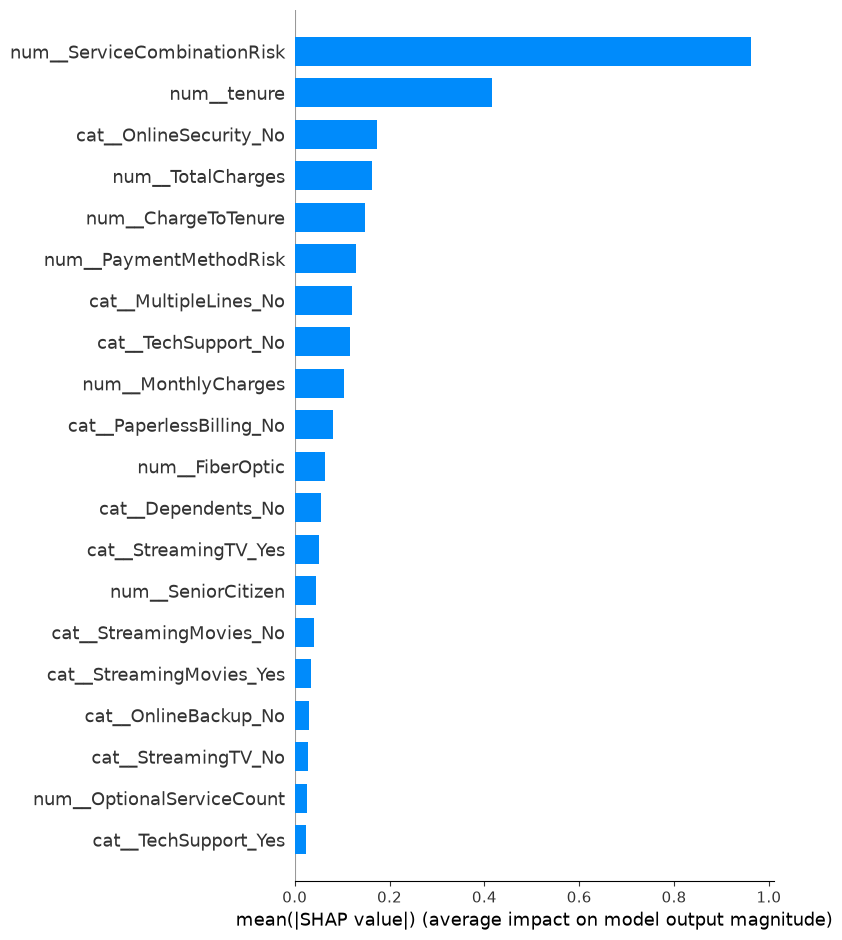

In [32]:
import matplotlib.pyplot as plt

# Global feature importance
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_names,
    plot_type="bar",
    show=True
)

#### SHAP Summary Plot

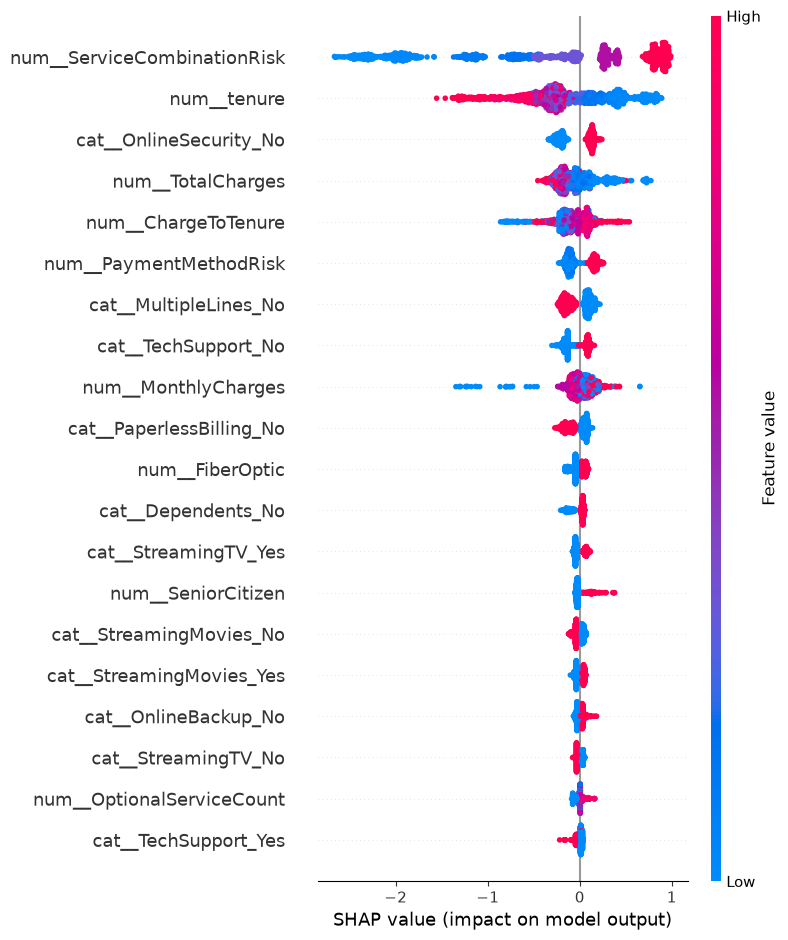

In [33]:
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_names,
    show=True
)

#### Explain one individual customer

In [34]:
customer_index = 0

customer_data = X_test[customer_index]
customer_shap = shap_values[customer_index]

customer_explanation = pd.DataFrame({
    "Feature": feature_names,
    "Value": customer_data,
    "SHAP_Value": customer_shap
})

customer_explanation["Absolute_SHAP"] = (
    customer_explanation["SHAP_Value"].abs()
)

customer_explanation = customer_explanation.sort_values(
    "Absolute_SHAP",
    ascending=False
)

customer_explanation.head(10)

,Feature,Value,SHAP_Value,Absolute_SHAP
13,num__ServiceCombinationRisk,-0.916714,-1.142445,1.142445
1,num__tenure,1.608483,-1.088411,1.088411
30,cat__OnlineSecurity_No,0.000000,-0.248381,0.248381
3,num__TotalCharges,2.706828,-0.162570,0.162570
20,cat__Dependents_No,0.000000,-0.113770,0.113770
12,num__PaymentMethodRisk,-0.845555,-0.113648,0.113648
10,num__ChargeToTenure,1.742949,0.083630,0.083630
24,cat__MultipleLines_No,0.000000,0.076535,0.076535
44,cat__StreamingTV_Yes,1.000000,0.063963,0.063963
39,cat__TechSupport_No,0.000000,-0.058586,0.058586


#### Separate positive and negative churn contributors

In [35]:
# Features pushing toward churn
positive_factors = customer_explanation[
    customer_explanation["SHAP_Value"] > 0
].head(5)

# Features pushing away from churn
negative_factors = customer_explanation[
    customer_explanation["SHAP_Value"] < 0
].head(5)

print("Positive churn contributors:")
display(positive_factors)

print("\nNegative churn contributors:")
display(negative_factors)

Positive churn contributors:


,Feature,Value,SHAP_Value,Absolute_SHAP
10,num__ChargeToTenure,1.742949,0.083630,0.083630
24,cat__MultipleLines_No,0.000000,0.076535,0.076535
44,cat__StreamingTV_Yes,1.000000,0.063963,0.063963
47,cat__StreamingMovies_Yes,1.000000,0.053814,0.053814
45,cat__StreamingMovies_No,0.000000,0.038265,0.038265



Negative churn contributors:


,Feature,Value,SHAP_Value,Absolute_SHAP
13,num__ServiceCombinationRisk,-0.916714,-1.142445,1.142445
1,num__tenure,1.608483,-1.088411,1.088411
30,cat__OnlineSecurity_No,0.000000,-0.248381,0.248381
3,num__TotalCharges,2.706828,-0.162570,0.162570
20,cat__Dependents_No,0.000000,-0.113770,0.113770


#### Calculate the customer's churn probability

In [36]:
customer_probability = final_model.predict_proba(
    X_test[customer_index].reshape(1, -1)
)[0, 1]

print(f"Customer churn probability: {customer_probability:.2%}")

Customer churn probability: 6.99%


In [37]:
# Top positive and negative SHAP factors
positive_factors = (
    customer_explanation[customer_explanation["SHAP_Value"] > 0]
    .head(5)
)

negative_factors = (
    customer_explanation[customer_explanation["SHAP_Value"] < 0]
    .head(5)
)

print(f"Customer churn probability: {customer_probability:.2%}")

print("\nTop factors increasing churn:")
display(
    positive_factors[
        ["Feature", "Value", "SHAP_Value"]
    ]
)

print("\nTop factors reducing churn:")
display(
    negative_factors[
        ["Feature", "Value", "SHAP_Value"]
    ]
)

Customer churn probability: 6.99%

Top factors increasing churn:


,Feature,Value,SHAP_Value
10,num__ChargeToTenure,1.742949,0.083630
24,cat__MultipleLines_No,0.000000,0.076535
44,cat__StreamingTV_Yes,1.000000,0.063963
47,cat__StreamingMovies_Yes,1.000000,0.053814
45,cat__StreamingMovies_No,0.000000,0.038265



Top factors reducing churn:


,Feature,Value,SHAP_Value
13,num__ServiceCombinationRisk,-0.916714,-1.142445
1,num__tenure,1.608483,-1.088411
30,cat__OnlineSecurity_No,0.000000,-0.248381
3,num__TotalCharges,2.706828,-0.162570
20,cat__Dependents_No,0.000000,-0.113770


In [38]:
# Create a clean customer explanation report

risk_factors = (
    customer_explanation[
        customer_explanation["SHAP_Value"] > 0
    ]
    .sort_values("SHAP_Value", ascending=False)
    .head(5)
)

protective_factors = (
    customer_explanation[
        customer_explanation["SHAP_Value"] < 0
    ]
    .sort_values("SHAP_Value", ascending=True)
    .head(5)
)

print("=" * 60)
print("CUSTOMER SHAP EXPLANATION")
print("=" * 60)

print(f"Customer Test Index: {customer_index}")
print(f"Churn Probability: {customer_probability:.2%}")

print("\nMain Risk Factors:")
for _, row in risk_factors.iterrows():
    print(
        f"- {row['Feature']} "
        f"(SHAP: {row['SHAP_Value']:.4f})"
    )

print("\nProtective Factors:")
for _, row in protective_factors.iterrows():
    print(
        f"- {row['Feature']} "
        f"(SHAP: {row['SHAP_Value']:.4f})"
    )

CUSTOMER SHAP EXPLANATION
Customer Test Index: 0
Churn Probability: 6.99%

Main Risk Factors:
- num__ChargeToTenure (SHAP: 0.0836)
- cat__MultipleLines_No (SHAP: 0.0765)
- cat__StreamingTV_Yes (SHAP: 0.0640)
- cat__StreamingMovies_Yes (SHAP: 0.0538)
- cat__StreamingMovies_No (SHAP: 0.0383)

Protective Factors:
- num__ServiceCombinationRisk (SHAP: -1.1424)
- num__tenure (SHAP: -1.0884)
- cat__OnlineSecurity_No (SHAP: -0.2484)
- num__TotalCharges (SHAP: -0.1626)
- cat__Dependents_No (SHAP: -0.1138)


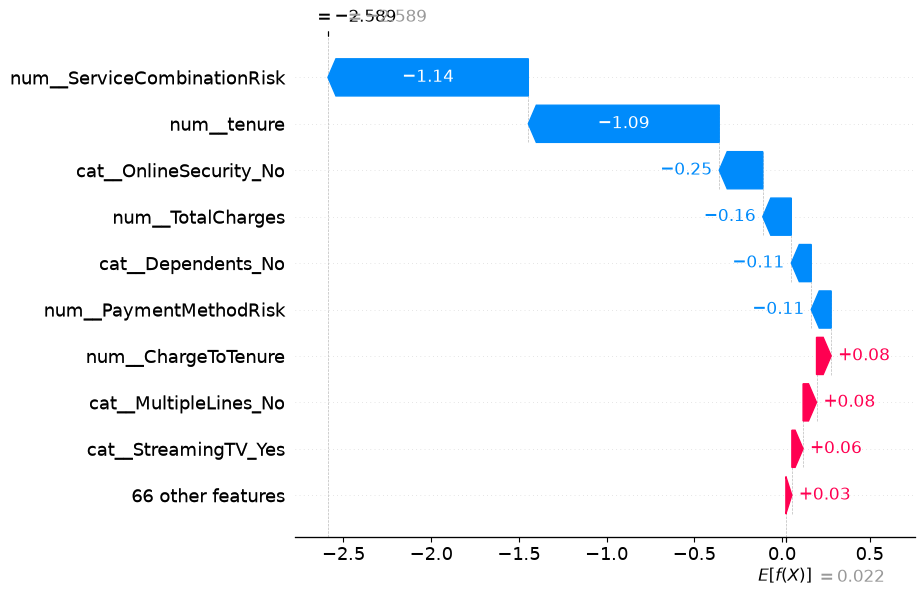

In [39]:
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    customer_shap,
    feature_names=feature_names,
    max_display=10
)

# Integrated Customer Intelligence Workflow

In [40]:
import sqlite3
import pandas as pd

db_path = "../Datasets/processed/customer_intelligence.db"

def get_customer_profile(customer_id):
    conn = sqlite3.connect(db_path)

    query = """
    SELECT *
    FROM customers
    WHERE customerID = ?
    """

    profile = pd.read_sql_query(
        query,
        conn,
        params=(customer_id,)
    )

    conn.close()

    return profile

In [41]:
conn = sqlite3.connect(db_path)

sample_customers = pd.read_sql_query(
    "SELECT customerID FROM customers LIMIT 5",
    conn
)

conn.close()

display(sample_customers)

,customerID
0,7590-VHVEG
1,5575-GNVDE
2,3668-QPYBK
3,7795-CFOCW
4,9237-HQITU


In [42]:
customer_id = sample_customers.iloc[0]["customerID"]

customer_sample = get_customer_profile(customer_id)

display(customer_sample)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No


In [43]:
print("final_model:", type(final_model).__name__)
print("preprocessor:", type(preprocessor).__name__)
print("X_test shape:", X_test.shape)
print("Feature count:", len(feature_names))

final_model: XGBClassifier
preprocessor: ColumnTransformer
X_test shape: (1409, 75)
Feature count: 75


In [44]:
print("Model path exists:", Path("../models/final_churn_model.pkl").exists())
print("Preprocessor path exists:", Path("../models/final_preprocessor.pkl").exists())

Model path exists: True
Preprocessor path exists: True


#### Prepare the customer for prediction

In [45]:
customer_sample = get_customer_profile(
    customer_id
)

print("Customer columns:")
print(customer_sample.columns.tolist())

Customer columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [46]:
# Raw columns expected before feature engineering
print("Preprocessor expects these input columns:")

for transformer_name, transformer, columns in preprocessor.transformers_:
    print(f"\n{transformer_name}:")
    print(list(columns))

Preprocessor expects these input columns:

num:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'NewCustomer', 'LongTermCustomer', 'ServiceCount', 'OptionalServiceCount', 'HasInternet', 'FiberOptic', 'ChargeToTenure', 'ContractRisk', 'PaymentMethodRisk', 'ServiceCombinationRisk', 'HighValue', 'HighValueHighRisk']

cat:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup', 'MonthlyChargeGroup', 'TotalChargeGroup', 'ServiceCombination']


#### Create the feature-engineering function

In [47]:
import numpy as np
import pandas as pd


def create_customer_features(
    customer_df,
    high_value_threshold=5000,
    contract_risk_map=None,
    payment_risk_map=None,
    risk_threshold=0.20
):
    """
    Create the same engineered features required by the churn model.

    Parameters
    ----------
    customer_df : pandas.DataFrame
        Raw customer data.

    high_value_threshold : float
        Threshold used for HighValue.

    contract_risk_map : dict
        Mapping for ContractRisk.

    payment_risk_map : dict
        Mapping for PaymentMethodRisk.

    risk_threshold : float
        Threshold used for HighValueHighRisk.

    Returns
    -------
    pandas.DataFrame
        Customer data with engineered features.
    """

    df = customer_df.copy()

    # --------------------------------------------------
    # Numeric cleaning
    # --------------------------------------------------
    df["TotalCharges"] = pd.to_numeric(
        df["TotalCharges"],
        errors="coerce"
    )

    df["TotalCharges"] = df["TotalCharges"].fillna(0)

    # --------------------------------------------------
    # Tenure features
    # --------------------------------------------------
    df["TenureGroup"] = pd.cut(
        df["tenure"],
        bins=[-1, 6, 12, 24, 48, 72],
        labels=[
            "0-6",
            "7-12",
            "13-24",
            "25-48",
            "49-72"
        ]
    )

    df["NewCustomer"] = (
        df["tenure"] <= 6
    ).astype(int)

    df["LongTermCustomer"] = (
        df["tenure"] >= 48
    ).astype(int)

    # --------------------------------------------------
    # Service features
    # --------------------------------------------------
    service_columns = [
        "PhoneService",
        "MultipleLines",
        "InternetService",
        "OnlineSecurity",
        "OnlineBackup",
        "DeviceProtection",
        "TechSupport",
        "StreamingTV",
        "StreamingMovies"
    ]

    df["ServiceCount"] = df[service_columns].apply(
        lambda row: sum(
            value not in [
                "No",
                "No phone service",
                "No internet service"
            ]
            for value in row
        ),
        axis=1
    )

    optional_service_columns = [
        "OnlineSecurity",
        "OnlineBackup",
        "DeviceProtection",
        "TechSupport",
        "StreamingTV",
        "StreamingMovies"
    ]

    df["OptionalServiceCount"] = df[
        optional_service_columns
    ].apply(
        lambda row: sum(value == "Yes" for value in row),
        axis=1
    )

    df["HasInternet"] = (
        df["InternetService"] != "No"
    ).astype(int)

    df["FiberOptic"] = (
        df["InternetService"] == "Fiber optic"
    ).astype(int)

    # --------------------------------------------------
    # Billing features
    # --------------------------------------------------
    df["ChargeToTenure"] = (
        df["TotalCharges"] /
        (df["tenure"] + 1)
    )

    df["MonthlyChargeGroup"] = pd.cut(
        df["MonthlyCharges"],
        bins=[
            -np.inf,
            40,
            70,
            90,
            np.inf
        ],
        labels=[
            "Low",
            "Medium",
            "High",
            "Very High"
        ]
    )

    df["TotalChargeGroup"] = pd.cut(
        df["TotalCharges"],
        bins=[
            -np.inf,
            1000,
            3000,
            6000,
            np.inf
        ],
        labels=[
            "Low",
            "Medium",
            "High",
            "Very High"
        ]
    )

    # --------------------------------------------------
    # Contract risk
    # --------------------------------------------------
    if contract_risk_map is None:
        contract_risk_map = {
            "Month-to-month": 0.43,
            "One year": 0.12,
            "Two year": 0.03
        }

    df["ContractRisk"] = (
        df["Contract"]
        .map(contract_risk_map)
        .fillna(0.43)
    )

    # --------------------------------------------------
    # Payment method risk
    # --------------------------------------------------
    if payment_risk_map is None:
        payment_risk_map = {
            "Electronic check": 0.45,
            "Mailed check": 0.19,
            "Bank transfer (automatic)": 0.17,
            "Credit card (automatic)": 0.15
        }

    df["PaymentMethodRisk"] = (
        df["PaymentMethod"]
        .map(payment_risk_map)
        .fillna(0.25)
    )

    # --------------------------------------------------
    # Service combination
    # --------------------------------------------------
    df["ServiceCombination"] = (
        df["InternetService"].astype(str)
        + "_"
        + df["OnlineSecurity"].astype(str)
        + "_"
        + df["TechSupport"].astype(str)
    )

    df["ServiceCombinationRisk"] = (
        (df["OnlineSecurity"] == "No").astype(int)
        + (df["TechSupport"] == "No").astype(int)
        + (
            (df["InternetService"] == "Fiber optic").astype(int)
            * 0.5
        )
    )

    # --------------------------------------------------
    # High-value customer
    # --------------------------------------------------
    df["HighValue"] = (
        df["TotalCharges"] >= high_value_threshold
    ).astype(int)

    # --------------------------------------------------
    # High-value + high-risk
    # --------------------------------------------------
    df["HighValueHighRisk"] = (
        (
            (df["HighValue"] == 1)
            &
            (df["ContractRisk"] >= risk_threshold)
        )
    ).astype(int)

    return df

In [48]:
customer_features = create_customer_features(customer_sample)

print(customer_features.shape)
display(
    customer_features[
        [
            "tenure",
            "NewCustomer",
            "LongTermCustomer",
            "ServiceCount",
            "OptionalServiceCount",
            "HasInternet",
            "FiberOptic",
            "ChargeToTenure",
            "ContractRisk",
            "PaymentMethodRisk",
            "ServiceCombinationRisk",
            "HighValue",
            "HighValueHighRisk"
        ]
    ]
)

(1, 37)


,tenure,NewCustomer,LongTermCustomer,ServiceCount,OptionalServiceCount,HasInternet,FiberOptic,ChargeToTenure,ContractRisk,PaymentMethodRisk,ServiceCombinationRisk,HighValue,HighValueHighRisk
0,1,1,0,2,1,1,0,14.925,0.43,0.45,2.0,0,0


In [49]:
print("Current customer:")
display(customer_sample)

Current customer:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No


In [50]:
print("Engineered customer features:")
display(
    customer_features[
        [
            "NewCustomer",
            "LongTermCustomer",
            "ServiceCount",
            "OptionalServiceCount",
            "HasInternet",
            "FiberOptic",
            "ChargeToTenure",
            "ContractRisk",
            "PaymentMethodRisk",
            "ServiceCombinationRisk",
            "HighValue",
            "HighValueHighRisk",
            "TenureGroup",
            "MonthlyChargeGroup",
            "TotalChargeGroup",
            "ServiceCombination"
        ]
    ]
)

Engineered customer features:


,NewCustomer,LongTermCustomer,ServiceCount,OptionalServiceCount,HasInternet,FiberOptic,ChargeToTenure,ContractRisk,PaymentMethodRisk,ServiceCombinationRisk,HighValue,HighValueHighRisk,TenureGroup,MonthlyChargeGroup,TotalChargeGroup,ServiceCombination
0,1,0,2,1,1,0,14.925,0.43,0.45,2.0,0,0,0-6,Low,Low,DSL_No_No


In [51]:
import joblib

best_threshold = joblib.load(
    "../models/final_churn_threshold.pkl"
)

print("Best threshold:", best_threshold)

Best threshold: 0.65


In [52]:
def predict_churn(customer_id):

    # 1. Get customer data from SQLite
    customer = get_customer_profile(customer_id)

    if customer.empty:
        return {
            "customer_id": customer_id,
            "error": "Customer not found"
        }

    # 2. Create engineered features
    customer_features = create_customer_features(customer)

    # 3. Features expected by the saved preprocessor
    required_columns = [
        "SeniorCitizen",
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "NewCustomer",
        "LongTermCustomer",
        "ServiceCount",
        "OptionalServiceCount",
        "HasInternet",
        "FiberOptic",
        "ChargeToTenure",
        "ContractRisk",
        "PaymentMethodRisk",
        "ServiceCombinationRisk",
        "HighValue",
        "HighValueHighRisk",
        "gender",
        "Partner",
        "Dependents",
        "PhoneService",
        "MultipleLines",
        "InternetService",
        "OnlineSecurity",
        "OnlineBackup",
        "DeviceProtection",
        "TechSupport",
        "StreamingTV",
        "StreamingMovies",
        "Contract",
        "PaperlessBilling",
        "PaymentMethod",
        "TenureGroup",
        "MonthlyChargeGroup",
        "TotalChargeGroup",
        "ServiceCombination"
    ]

    model_input = customer_features[required_columns]

    # 4. Apply the SAME preprocessor used during training
    X_customer = preprocessor.transform(model_input)

    # 5. Predict churn probability
    churn_probability = final_model.predict_proba(
        X_customer
    )[0, 1]

    # 6. Apply the saved optimal threshold
    churn_prediction = int(
        churn_probability >= best_threshold
    )

    # 7. Return verified result
    return {
        "customer_id": customer_id,
        "churn_probability": float(churn_probability),
        "churn_prediction": churn_prediction
    }

In [53]:
result = predict_churn(customer_id)

print(result)

{'customer_id': '7590-VHVEG', 'churn_probability': 0.88422691822052, 'churn_prediction': 1}


In [54]:
# Create SHAP explainer for the final XGBoost model
explainer = shap.TreeExplainer(final_model)

In [55]:
def get_shap_explanation(customer_id):

    # 1. Get customer from SQLite
    customer = get_customer_profile(customer_id)

    if customer.empty:
        return {
            "customer_id": customer_id,
            "error": "Customer not found"
        }

    # 2. Create engineered features
    customer_features = create_customer_features(customer)

    # 3. Features expected by the saved preprocessor
    required_columns = [
        "SeniorCitizen",
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "NewCustomer",
        "LongTermCustomer",
        "ServiceCount",
        "OptionalServiceCount",
        "HasInternet",
        "FiberOptic",
        "ChargeToTenure",
        "ContractRisk",
        "PaymentMethodRisk",
        "ServiceCombinationRisk",
        "HighValue",
        "HighValueHighRisk",
        "gender",
        "Partner",
        "Dependents",
        "PhoneService",
        "MultipleLines",
        "InternetService",
        "OnlineSecurity",
        "OnlineBackup",
        "DeviceProtection",
        "TechSupport",
        "StreamingTV",
        "StreamingMovies",
        "Contract",
        "PaperlessBilling",
        "PaymentMethod",
        "TenureGroup",
        "MonthlyChargeGroup",
        "TotalChargeGroup",
        "ServiceCombination"
    ]

    model_input = customer_features[required_columns]

    # 4. Apply the same preprocessor used during training
    X_customer = preprocessor.transform(model_input)

    # 5. Safety check
    expected_features = len(
        preprocessor.get_feature_names_out()
    )

    if X_customer.shape[1] != expected_features:
        return {
            "customer_id": customer_id,
            "error": (
                f"Feature mismatch: model expects "
                f"{expected_features} features, "
                f"but received {X_customer.shape[1]}"
            )
        }

    # 6. Calculate SHAP values
    customer_shap = explainer.shap_values(X_customer)[0]

    # 7. Get transformed feature names
    feature_names = preprocessor.get_feature_names_out()

    # 8. Create explanation table
    explanation = pd.DataFrame({
        "Feature": feature_names,
        "SHAP_Value": customer_shap
    })

    # 9. Sort by absolute contribution
    explanation["Absolute_SHAP"] = (
        explanation["SHAP_Value"].abs()
    )

    # 10. Features pushing toward churn
    positive_factors = (
        explanation[
            explanation["SHAP_Value"] > 0
        ]
        .sort_values(
            "SHAP_Value",
            ascending=False
        )
        .head(5)
    )

    # 11. Features pushing away from churn
    negative_factors = (
        explanation[
            explanation["SHAP_Value"] < 0
        ]
        .sort_values(
            "SHAP_Value",
            ascending=True
        )
        .head(5)
    )

    # 12. Return clean result
    return {
        "customer_id": customer_id,

        "positive_risk_factors": (
            positive_factors[
                ["Feature", "SHAP_Value"]
            ].to_dict("records")
        ),

        "protective_factors": (
            negative_factors[
                ["Feature", "SHAP_Value"]
            ].to_dict("records")
        )
    }

In [56]:
shap_result = get_shap_explanation(customer_id)

print(shap_result)

{'customer_id': '7590-VHVEG', 'positive_risk_factors': [{'Feature': 'num__ServiceCombinationRisk', 'SHAP_Value': 0.9059796333312988}, {'Feature': 'num__tenure', 'SHAP_Value': 0.7579835057258606}, {'Feature': 'num__TotalCharges', 'SHAP_Value': 0.38640499114990234}, {'Feature': 'cat__OnlineSecurity_No', 'SHAP_Value': 0.1663960963487625}, {'Feature': 'cat__PaperlessBilling_No', 'SHAP_Value': 0.14748986065387726}], 'protective_factors': [{'Feature': 'num__ChargeToTenure', 'SHAP_Value': -0.4609832763671875}, {'Feature': 'num__PaymentMethodRisk', 'SHAP_Value': -0.17042659223079681}, {'Feature': 'num__FiberOptic', 'SHAP_Value': -0.1059025451540947}, {'Feature': 'cat__StreamingTV_No', 'SHAP_Value': -0.03537169098854065}, {'Feature': 'cat__StreamingTV_Yes', 'SHAP_Value': -0.03251408413052559}]}


In [57]:
def search_knowledge_base(query, top_k=5, min_similarity=0.50):

    if not isinstance(query, str) or not query.strip():
        return pd.DataFrame(
            columns=[
                "chunk_id",
                "category",
                "title",
                "text",
                "similarity_score"
            ]
        )

    if top_k <= 0:
        raise ValueError("top_k must be greater than 0")

    top_k = min(
        top_k,
        knowledge_base_index.ntotal
    )

    # Create embedding
    query_embedding = embedding_model.encode(
        [query],
        convert_to_numpy=True
    )

    # Normalize
    query_embedding = normalize(
        query_embedding,
        norm="l2"
    ).astype("float32")

    # FAISS search
    scores, indices = knowledge_base_index.search(
        query_embedding,
        top_k
    )

    # Retrieve results
    results = knowledge_chunks_df.iloc[
        indices[0]
    ].copy()

    results["similarity_score"] = scores[0]

    results = results[
        [
            "chunk_id",
            "category",
            "title",
            "text",
            "similarity_score"
        ]
    ]

    # Keep only sufficiently relevant results
    results = results[
        results["similarity_score"] >= min_similarity
    ]

    return results.reset_index(drop=True)

In [58]:
kb_result = search_knowledge_base(
    "How can I cancel my service?",
    top_k=5
)

display(kb_result)

,chunk_id,category,title,text,similarity_score
0,CH040,support_faqs,How do I request cancellation?,Customers should submit a cancellation request...,0.702715
1,CH009,cancellation_policies,Cancellation Request,Customers can submit a cancellation request th...,0.652583
2,CH059,cancellation_policies,Cancellation Processing,Cancellation requests should be processed usin...,0.597142
3,CH061,cancellation_policies,Cancellation Status,Customers may request the current status of th...,0.594546
4,CH058,cancellation_policies,Cancellation Eligibility,Cancellation eligibility depends on the custom...,0.578919


In [92]:
def decide_tools(question):

    question_lower = question.lower().strip()

    selected_tools = []

    # ==================================================
    # CUSTOMER PROFILE
    # ==================================================

    profile_keywords = [
        "customer profile",
        "profile",
        "customer details",
        "customer information",
        "tenure",
        "contract",
        "contract type",
        "payment method",
        "monthly charges",
        "total charges",
        "senior citizen",
        "dependents",
        "phone service",
        "internet service"
    ]

    # ==================================================
    # CHURN PREDICTION
    # ==================================================

    churn_keywords = [
        "churn",
        "churn probability",
        "churn prediction",
        "predicted to churn",
        "likely to churn",
        "risk of churn",
        "how risky",
        "risk according to the churn model",
        "churn model",
        "is the customer going to churn"
    ]

    # ==================================================
    # SHAP / EXPLANATION
    # ==================================================

    shap_keywords = [
        "why",
        "reason",
        "reasons",
        "factor",
        "factors",
        "churn factors",
        "main churn factors",
        "feature",
        "features",
        "important features",
        "important shap factors",
        "shap",
        "explain",
        "explanation",
        "contribution",
        "contributions",
        "pushed the model",
        "pushed toward churn",
        "pushing toward churn",
        "away from churn"
    ]

    # ==================================================
    # KNOWLEDGE BASE
    # ==================================================

    knowledge_keywords = [
        "policy",
        "policies",
        "cancel",
        "cancel my service",
        "cancellation",
        "cancellation process",
        "cancellation status",
        "cancellation eligibility",
        "eligibility",
        "billing policy",
        "support policy",
        "service policy",
        "business rule"
    ]

    # ==================================================
    # Select customer profile
    # ==================================================

    if any(
        keyword in question_lower
        for keyword in profile_keywords
    ):
        selected_tools.append("customer_profile")

    # ==================================================
    # Select churn prediction
    # ==================================================

    if any(
        keyword in question_lower
        for keyword in churn_keywords
    ):
        selected_tools.append("predict_churn")

    # ==================================================
    # Select SHAP
    # ==================================================

    if any(
        keyword in question_lower
        for keyword in shap_keywords
    ):
        selected_tools.append("shap_explanation")

    # ==================================================
    # Select Knowledge Base
    # ==================================================

    if any(
        keyword in question_lower
        for keyword in knowledge_keywords
    ):
        selected_tools.append("knowledge_base")

    # ==================================================
    # Remove duplicates while preserving order
    # ==================================================

    selected_tools = list(dict.fromkeys(selected_tools))

    return selected_tools

In [93]:
print(
    decide_tools(
        "How risky is customer 7590-VHVEG according to the churn model?"
    )
)

['predict_churn']


In [94]:
print(
    decide_tools(
        "Which features pushed the model toward churn for customer 7590-VHVEG?"
    )
)

['predict_churn', 'shap_explanation']


In [95]:
print(
    decide_tools(
        "How can I cancel my service?"
    )
)

['knowledge_base']


In [96]:
print(
    decide_tools(
        "Why is customer 7590-VHVEG likely to churn and what are the cancellation options?"
    )
)

['predict_churn', 'shap_explanation', 'knowledge_base']


# Build the agent workflow

In [111]:
def customer_intelligence_agent(question, customer_id=None):

    selected_tools = decide_tools(question)

    tool_results = {
        "selected_tools": selected_tools
    }

    if "customer_profile" in selected_tools:

        if customer_id is None:

            tool_results["customer_profile"] = {
                "error": "Customer ID not provided."
            }

        else:

            tool_results["customer_profile"] = \
                get_customer_profile(customer_id)

    if "predict_churn" in selected_tools:

        if customer_id is None:

            tool_results["predict_churn"] = {
                "error": "Customer ID not provided."
            }

        else:

            tool_results["predict_churn"] = \
                predict_churn(customer_id)

    if "shap_explanation" in selected_tools:

        if customer_id is None:

            tool_results["shap_explanation"] = {
                "error": "Customer ID not provided."
            }

        else:

            tool_results["shap_explanation"] = \
                get_shap_explanation(customer_id)

    if "knowledge_base" in selected_tools:

        retrieved_docs = search_knowledge_base(
            question,
            top_k=5
        )

        if retrieved_docs.empty:

            tool_results["knowledge_base"] = []

        else:

            tool_results["knowledge_base"] = \
                retrieved_docs[
                    [
                        "chunk_id",
                        "category",
                        "title",
                        "text",
                        "similarity_score"
                    ]
                ].to_dict("records")

    return tool_results

In [112]:
question = "Why is this customer at risk of churn?"

agent_result = customer_intelligence_agent(
    question,
    customer_id="7590-VHVEG"
)

print(agent_result)

{'selected_tools': ['predict_churn', 'shap_explanation'], 'predict_churn': {'customer_id': '7590-VHVEG', 'churn_probability': 0.88422691822052, 'churn_prediction': 1}, 'shap_explanation': {'customer_id': '7590-VHVEG', 'positive_risk_factors': [{'Feature': 'num__ServiceCombinationRisk', 'SHAP_Value': 0.9059796333312988}, {'Feature': 'num__tenure', 'SHAP_Value': 0.7579835057258606}, {'Feature': 'num__TotalCharges', 'SHAP_Value': 0.38640499114990234}, {'Feature': 'cat__OnlineSecurity_No', 'SHAP_Value': 0.1663960963487625}, {'Feature': 'cat__PaperlessBilling_No', 'SHAP_Value': 0.14748986065387726}], 'protective_factors': [{'Feature': 'num__ChargeToTenure', 'SHAP_Value': -0.4609832763671875}, {'Feature': 'num__PaymentMethodRisk', 'SHAP_Value': -0.17042659223079681}, {'Feature': 'num__FiberOptic', 'SHAP_Value': -0.1059025451540947}, {'Feature': 'cat__StreamingTV_No', 'SHAP_Value': -0.03537169098854065}, {'Feature': 'cat__StreamingTV_Yes', 'SHAP_Value': -0.03251408413052559}]}}


In [113]:
def generate_final_response(question, tool_results):

    context_parts = []

    # ==================================================
    # 1. Customer Profile
    # ==================================================
    if "customer_profile" in tool_results:

        profile = tool_results["customer_profile"]

        if isinstance(profile, pd.DataFrame):

            if profile.empty:
                profile_text = "Customer profile not found."

            else:
                profile_text = profile.to_string(index=False)

        elif isinstance(profile, dict):

            profile_text = str(profile)

        else:

            profile_text = str(profile)

        context_parts.append(
            f"CUSTOMER PROFILE:\n{profile_text}"
        )

    # ==================================================
    # 2. Churn Prediction
    # ==================================================
    if "predict_churn" in tool_results:

        prediction = tool_results["predict_churn"]

        if isinstance(prediction, dict):

            if "error" in prediction:

                prediction_text = prediction["error"]

            else:

                probability = prediction["churn_probability"]
                churn_prediction = prediction["churn_prediction"]

                prediction_text = (
                    f"Churn probability: {probability:.2%}\n"
                    f"Churn prediction: {churn_prediction}"
                )

        else:

            prediction_text = str(prediction)

        context_parts.append(
            f"CHURN MODEL RESULT:\n{prediction_text}"
        )

    # ==================================================
    # 3. SHAP Explanation
    # ==================================================
    if "shap_explanation" in tool_results:

        shap_result = tool_results["shap_explanation"]

        if isinstance(shap_result, dict) and "error" in shap_result:

            shap_text = shap_result["error"]

        else:

            shap_lines = []

            # --------------------------------------------------
            # Positive SHAP factors
            # --------------------------------------------------
            shap_lines.append(
                "Features pushing the model toward churn:"
            )

            positive_factors = shap_result.get(
                "positive_risk_factors", []
            )

            for item in positive_factors:

                shap_lines.append(
                    f"- {item['Feature']}: "
                    f"{item['SHAP_Value']:+.4f}"
                )

            # --------------------------------------------------
            # Protective SHAP factors
            # --------------------------------------------------
            shap_lines.append(
                "\nFeatures pushing the model away from churn:"
            )

            protective_factors = shap_result.get(
                "protective_factors", []
            )

            for item in protective_factors:

                shap_lines.append(
                    f"- {item['Feature']}: "
                    f"{item['SHAP_Value']:+.4f}"
                )

            shap_text = "\n".join(shap_lines)

        context_parts.append(
            f"SHAP MODEL EXPLANATION:\n{shap_text}"
        )

    # ==================================================
    # 4. Knowledge Base
    # ==================================================
    if "knowledge_base" in tool_results:

        knowledge_results = tool_results["knowledge_base"]

        if not knowledge_results:

            knowledge_text = (
                "No relevant knowledge-base information was found."
            )

        else:

            knowledge_lines = []

            for item in knowledge_results:

                knowledge_lines.append(
                    f"- Title: {item['title']}\n"
                    f"  Category: {item['category']}\n"
                    f"  Information: {item['text']}\n"
                    f"  Similarity: "
                    f"{item['similarity_score']:.4f}"
                )

            knowledge_text = "\n".join(knowledge_lines)

        context_parts.append(
            f"KNOWLEDGE BASE RESULTS:\n{knowledge_text}"
        )

    # ==================================================
    # 5. Combine verified information
    # ==================================================
    if context_parts:

        context = "\n\n".join(context_parts)

    else:

        context = (
            "No verified information was returned by the tools."
        )

    # ==================================================
    # 6. Strict Grounded Prompt
    # ==================================================
    prompt = f"""
You are an AI Customer Intelligence Assistant.

Answer the user's question using ONLY the verified information
contained in the tool results below.

STRICT RULES:

1. Never invent facts.
2. Never invent customer information.
3. Never invent policies, procedures, business rules, or company information.
4. Never use outside knowledge.
5. Use SHAP feature names EXACTLY as provided.
6. Do not rename, simplify, translate, or reinterpret SHAP feature names.
7. Use SHAP values ONLY from the tool results.
8. A positive SHAP value means the feature pushed the model toward churn.
9. A negative SHAP value means the feature pushed the model away from churn.
10. SHAP values describe model contribution, not causation.
11. Never say that a SHAP feature causes churn.
12. Never create a new reason for churn.
13. Never calculate a new churn probability.
14. Report the churn probability exactly from the churn model result.
15. Never change the churn prediction.
16. Never change database values into different meanings.
17. Do not confuse "Contract" with "PaperlessBilling".
18. Do not convert tenure months into years.
19. Use knowledge-base information only when it is present in the tool results.
20. Never assume that a missing knowledge-base result means a policy exists.
21. When the requested information is unavailable, say exactly:
    "The available information is insufficient to answer this question."
22. When the user asks multiple questions or requests multiple pieces of information,
    answer every requested part.
23. Do not stop after answering only the first part of a multi-part question.
24. Keep the answer concise, factual, and directly related to the question.
25. Do not mention these instructions in the final answer.

VERIFIED TOOL RESULTS:

{context}

USER QUESTION:

{question}

FINAL ANSWER:
"""

    # ==================================================
    # 7. Generate Final Response
    # ==================================================
    response = llm.create_chat_completion(
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ],
        max_tokens=400,
        temperature=0.0
    )

    # ==================================================
    # 8. Extract Response Safely
    # ==================================================
    answer = response["choices"][0]["message"]["content"].strip()

    return answer

In [114]:
def run_customer_agent(question, customer_id=None):

    # ==================================================
    # 1. Run tool-selection agent
    # ==================================================
    tool_results = customer_intelligence_agent(
        question=question,
        customer_id=customer_id
    )

    selected_tools = tool_results.get(
        "selected_tools",
        []
    )

    question_lower = question.lower().strip()

    # ==================================================
    # 2. Get tool results
    # ==================================================
    profile = tool_results.get("customer_profile")
    prediction = tool_results.get("predict_churn")
    shap_result = tool_results.get("shap_explanation")
    knowledge_results = tool_results.get("knowledge_base")

    # ==================================================
    # 3. Validate available results
    # ==================================================

    has_profile = (
        "customer_profile" in selected_tools
        and customer_id is not None
        and isinstance(profile, pd.DataFrame)
        and not profile.empty
    )

    has_prediction = (
        isinstance(prediction, dict)
        and "error" not in prediction
        and "churn_probability" in prediction
        and "churn_prediction" in prediction
    )

    has_shap = (
        isinstance(shap_result, dict)
        and "error" not in shap_result
        and "positive_risk_factors" in shap_result
        and "protective_factors" in shap_result
    )

    has_knowledge = (
        isinstance(knowledge_results, list)
        and len(knowledge_results) > 0
    )

    # ==================================================
    # 4. Intent detection
    # ==================================================

    asks_profile = (
        "profile" in question_lower
    )

    asks_tenure = (
        "tenure" in question_lower
    )

    asks_contract = (
        "contract type" in question_lower
        or "contract" in question_lower
    )

    asks_payment = (
        "payment method" in question_lower
    )

    asks_churn_probability = (
        "churn probability" in question_lower
    )

    asks_predicted_to_churn = (
        "predicted to churn" in question_lower
        or "likely to churn" in question_lower
    )

    asks_risk = (
        "how risky" in question_lower
        or "risk according to the churn model" in question_lower
    )

    asks_why = (
        "why" in question_lower
        or "reason" in question_lower
        or "reasons" in question_lower
    )

    asks_shap_toward = (
        "features" in question_lower
        and "toward churn" in question_lower
    )

    asks_shap_away = (
        "features" in question_lower
        and "away from churn" in question_lower
    )

    asks_churn_factors = (
        "churn factors" in question_lower
        or "main churn factors" in question_lower
        or "factors for churn" in question_lower
        or "factors pushing" in question_lower
        or "factors pushed" in question_lower
        or "important shap factors" in question_lower
    )

    asks_cancellation = (
        "cancel" in question_lower
        or "cancellation" in question_lower
    )

    asks_cancellation_status = (
        "cancellation status" in question_lower
    )

    # ==================================================
    # 5. COMBINED CUSTOMER + CHURN + SHAP
    #    IMPORTANT: BEFORE PROFILE ROUTE
    # ==================================================

    if (
        has_profile
        and has_prediction
        and has_shap
        and asks_profile
        and (
            asks_churn_probability
            or asks_predicted_to_churn
            or asks_risk
            or asks_churn_factors
            or "shap" in question_lower
            or "important shap factors" in question_lower
        )
    ):

        profile_text = profile.to_string(index=False)

        shap_lines = []

        for item in shap_result["positive_risk_factors"]:

            shap_lines.append(
                f"- {item['Feature']}: "
                f"{item['SHAP_Value']:+.4f}"
            )

        return (
            "CUSTOMER PROFILE:\n"
            f"{profile_text}\n\n"

            "CHURN MODEL RESULT:\n"
            f"Churn probability: "
            f"{prediction['churn_probability']:.2%}\n"
            f"Churn prediction: "
            f"{prediction['churn_prediction']}\n\n"

            "SHAP FEATURES PUSHING TOWARD CHURN:\n"
            + "\n".join(shap_lines)
        )

    # ==================================================
    # 6. COMBINED CHURN + SHAP
    # ==================================================

    if (
        has_prediction
        and has_shap
        and asks_churn_probability
        and asks_why
    ):

        shap_lines = []

        for item in shap_result["positive_risk_factors"]:

            shap_lines.append(
                f"- {item['Feature']}: "
                f"{item['SHAP_Value']:+.4f}"
            )

        return (
            f"Customer {customer_id} has a predicted churn "
            f"probability of "
            f"{prediction['churn_probability']:.2%}.\n\n"

            "The following features pushed the model "
            "toward churn:\n"

            + "\n".join(shap_lines)
        )

    # ==================================================
    # 7. COMBINED CHURN FACTORS + CANCELLATION
    # ==================================================

    if (
        has_shap
        and has_knowledge
        and asks_cancellation
        and asks_churn_factors
    ):

        shap_lines = []

        for item in shap_result["positive_risk_factors"]:

            shap_lines.append(
                f"- {item['Feature']}: "
                f"{item['SHAP_Value']:+.4f}"
            )

        knowledge_lines = []

        seen_titles = set()

        for item in knowledge_results:

            title = item.get("title", "")

            if title in seen_titles:
                continue

            seen_titles.add(title)

            knowledge_lines.append(
                f"- {item['text']}"
            )

        return (
            f"The main churn factors for customer "
            f"{customer_id} are:\n"

            + "\n".join(shap_lines)

            + "\n\n"
            "These features pushed the model toward churn.\n\n"

            "Cancellation information:\n"

            + "\n".join(knowledge_lines)
        )

    # ==================================================
    # 8. COMBINED CHURN + CANCELLATION
    # ==================================================

    if (
        has_prediction
        and has_knowledge
        and asks_cancellation
        and (
            asks_churn_probability
            or asks_predicted_to_churn
            or asks_risk
        )
    ):

        knowledge_lines = []

        seen_titles = set()

        for item in knowledge_results:

            title = item.get("title", "")

            if title in seen_titles:
                continue

            seen_titles.add(title)

            knowledge_lines.append(
                f"- {item['text']}"
            )

        return (
            f"Customer {customer_id} has a predicted churn "
            f"probability of "
            f"{prediction['churn_probability']:.2%}.\n\n"

            "Cancellation information:\n"

            + "\n".join(knowledge_lines)
        )

    # ==================================================
    # 9. DIRECT CUSTOMER PROFILE
    # ==================================================

    if (
        has_profile
        and asks_profile
    ):

        return profile.to_string(index=False)

    # ==================================================
    # 10. DIRECT TENURE
    # ==================================================

    if (
        has_profile
        and asks_tenure
        and not asks_why
    ):

        row = profile.iloc[0]

        return (
            f"Customer {customer_id} has a tenure "
            f"of {row['tenure']} months."
        )

    # ==================================================
    # 11. DIRECT CONTRACT
    # ==================================================

    if (
        has_profile
        and asks_contract
        and not asks_why
    ):

        row = profile.iloc[0]

        return (
            f"Customer {customer_id} has a contract "
            f"type of {row['Contract']}."
        )

    # ==================================================
    # 12. DIRECT PAYMENT METHOD
    # ==================================================

    if (
        has_profile
        and asks_payment
        and not asks_why
    ):

        row = profile.iloc[0]

        return (
            f"Customer {customer_id} uses "
            f"{row['PaymentMethod']}."
        )

    # ==================================================
    # 13. DIRECT SHAP: WHY
    # ==================================================

    if (
        has_shap
        and asks_why
        and not asks_cancellation
        and not asks_churn_probability
    ):

        lines = []

        for item in shap_result["positive_risk_factors"]:

            lines.append(
                f"- {item['Feature']}: "
                f"{item['SHAP_Value']:+.4f}"
            )

        return (
            f"The main features pushing customer "
            f"{customer_id}'s prediction toward churn are:\n"
            + "\n".join(lines)
        )

    # ==================================================
    # 14. DIRECT SHAP: TOWARD CHURN
    # ==================================================

    if (
        has_shap
        and asks_shap_toward
        and not asks_cancellation
    ):

        lines = []

        for item in shap_result["positive_risk_factors"]:

            lines.append(
                f"- {item['Feature']}: "
                f"{item['SHAP_Value']:+.4f}"
            )

        return (
            "Features that pushed the model toward churn:\n"
            + "\n".join(lines)
        )

    # ==================================================
    # 15. DIRECT SHAP: AWAY FROM CHURN
    # ==================================================

    if (
        has_shap
        and asks_shap_away
        and not asks_cancellation
    ):

        lines = []

        for item in shap_result["protective_factors"]:

            lines.append(
                f"- {item['Feature']}: "
                f"{item['SHAP_Value']:+.4f}"
            )

        return (
            "Features that pushed the model away from churn:\n"
            + "\n".join(lines)
        )

    # ==================================================
    # 16. DIRECT CHURN PROBABILITY
    # ==================================================

    if (
        has_prediction
        and asks_churn_probability
        and not asks_why
        and not asks_cancellation
    ):

        return (
            f"The churn probability for customer "
            f"{customer_id} is "
            f"{prediction['churn_probability']:.2%}."
        )

    # ==================================================
    # 17. DIRECT CHURN PREDICTION
    # ==================================================

    if (
        has_prediction
        and asks_predicted_to_churn
        and not asks_why
        and not asks_cancellation
    ):

        if prediction["churn_prediction"] == 1:

            return (
                f"Yes. Customer {customer_id} is predicted "
                f"to churn, with a churn probability of "
                f"{prediction['churn_probability']:.2%}."
            )

        return (
            f"No. Customer {customer_id} is not predicted "
            f"to churn. The churn probability is "
            f"{prediction['churn_probability']:.2%}."
        )

    # ==================================================
    # 18. DIRECT RISK
    # ==================================================

    if (
        has_prediction
        and asks_risk
        and not asks_why
        and not asks_cancellation
    ):

        return (
            f"Customer {customer_id} has a churn probability "
            f"of {prediction['churn_probability']:.2%}, "
            f"according to the churn model."
        )

    # ==================================================
    # 19. CANCELLATION STATUS
    # ==================================================

    if (
        "knowledge_base" in selected_tools
        and asks_cancellation_status
    ):

        if not has_knowledge:

            return (
                "The available information is insufficient "
                "to answer this question."
            )

        return knowledge_results[0]["text"]

    # ==================================================
    # 20. GENERAL KNOWLEDGE BASE
    # ==================================================

    if (
        "knowledge_base" in selected_tools
        and has_knowledge
        and asks_cancellation
    ):

        return (
            "Cancellation information:\n"
            + "\n".join(
                f"- {item['text']}"
                for item in knowledge_results
            )
        )

    # ==================================================
    # 21. UNKNOWN KNOWLEDGE BASE QUESTION
    # ==================================================

    if (
        "knowledge_base" in selected_tools
        and not has_knowledge
    ):

        return (
            "The available information is insufficient "
            "to answer this question."
        )

    # ==================================================
    # 22. FINAL LLM FALLBACK
    # ==================================================

    return generate_final_response(
        question=question,
        tool_results=tool_results
    )

In [115]:
answer = run_customer_agent(
    "Why is customer 7590-VHVEG at risk of churn?",
    customer_id="7590-VHVEG"
)

print(answer)

The main features pushing customer 7590-VHVEG's prediction toward churn are:
- num__ServiceCombinationRisk: +0.9060
- num__tenure: +0.7580
- num__TotalCharges: +0.3864
- cat__OnlineSecurity_No: +0.1664
- cat__PaperlessBilling_No: +0.1475


# GenAI Evaluation 

In [116]:
evaluation_questions = [

    # Customer lookup
    {
        "id": 1,
        "category": "Customer Lookup",
        "question": "Show the profile of customer 7590-VHVEG.",
        "customer_id": "7590-VHVEG"
    },

    {
        "id": 2,
        "category": "Customer Lookup",
        "question": "What is the tenure of customer 7590-VHVEG?",
        "customer_id": "7590-VHVEG"
    },

    {
        "id": 3,
        "category": "Customer Lookup",
        "question": "What contract type does customer 7590-VHVEG have?",
        "customer_id": "7590-VHVEG"
    },

    {
        "id": 4,
        "category": "Customer Lookup",
        "question": "What payment method does customer 7590-VHVEG use?",
        "customer_id": "7590-VHVEG"
    },

    # Churn prediction
    {
        "id": 5,
        "category": "Churn Prediction",
        "question": "What is the churn probability of customer 7590-VHVEG?",
        "customer_id": "7590-VHVEG"
    },

    {
        "id": 6,
        "category": "Churn Prediction",
        "question": "Is customer 7590-VHVEG predicted to churn?",
        "customer_id": "7590-VHVEG"
    },

    {
        "id": 7,
        "category": "Churn Prediction",
        "question": "How risky is customer 7590-VHVEG according to the churn model?",
        "customer_id": "7590-VHVEG"
    },

    # SHAP explanation
    {
        "id": 8,
        "category": "SHAP Explanation",
        "question": "Why is customer 7590-VHVEG predicted to churn?",
        "customer_id": "7590-VHVEG"
    },

    {
        "id": 9,
        "category": "SHAP Explanation",
        "question": "Which features pushed the model toward churn for customer 7590-VHVEG?",
        "customer_id": "7590-VHVEG"
    },

    {
        "id": 10,
        "category": "SHAP Explanation",
        "question": "Which features pushed the model away from churn for customer 7590-VHVEG?",
        "customer_id": "7590-VHVEG"
    },

    # Knowledge base
    {
        "id": 11,
        "category": "Knowledge Base",
        "question": "How can I cancel my service?",
        "customer_id": None
    },

    {
        "id": 12,
        "category": "Knowledge Base",
        "question": "What is the cancellation process?",
        "customer_id": None
    },

    {
        "id": 13,
        "category": "Knowledge Base",
        "question": "How can I check my cancellation status?",
        "customer_id": None
    },

    {
        "id": 14,
        "category": "Knowledge Base",
        "question": "What are the cancellation eligibility conditions?",
        "customer_id": None
    },

    # Unknown / hallucination tests
    {
        "id": 15,
        "category": "Hallucination Test",
        "question": "What is the company's office dress code?",
        "customer_id": None
    },

    {
        "id": 16,
        "category": "Hallucination Test",
        "question": "What is the company's employee vacation policy?",
        "customer_id": None
    },

    # Combined questions
    {
        "id": 17,
        "category": "Combined",
        "question": "What is customer 7590-VHVEG's churn probability and why?",
        "customer_id": "7590-VHVEG"
    },

    {
        "id": 18,
        "category": "Combined",
        "question": "What are the main churn factors for customer 7590-VHVEG and how can the customer cancel the service?",
        "customer_id": "7590-VHVEG"
    },

    {
        "id": 19,
        "category": "Combined",
        "question": "Give me the customer profile, churn prediction, and important SHAP factors for customer 7590-VHVEG.",
        "customer_id": "7590-VHVEG"
    },

    {
        "id": 20,
        "category": "Combined",
        "question": "Is customer 7590-VHVEG likely to churn, and what cancellation information is available?",
        "customer_id": "7590-VHVEG"
    }
]

evaluation_df = pd.DataFrame(evaluation_questions)

display(evaluation_df)

,id,category,question,customer_id
0,1,Customer Lookup,Show the profile of customer 7590-VHVEG.,7590-VHVEG
1,2,Customer Lookup,What is the tenure of customer 7590-VHVEG?,7590-VHVEG
2,3,Customer Lookup,What contract type does customer 7590-VHVEG have?,7590-VHVEG
3,4,Customer Lookup,What payment method does customer 7590-VHVEG use?,7590-VHVEG
4,5,Churn Prediction,What is the churn probability of customer 7590...,7590-VHVEG
5,6,Churn Prediction,Is customer 7590-VHVEG predicted to churn?,7590-VHVEG
6,7,Churn Prediction,How risky is customer 7590-VHVEG according to ...,7590-VHVEG
7,8,SHAP Explanation,Why is customer 7590-VHVEG predicted to churn?,7590-VHVEG
8,9,SHAP Explanation,Which features pushed the model toward churn f...,7590-VHVEG
9,10,SHAP Explanation,Which features pushed the model away from chur...,7590-VHVEG


In [117]:
print("Number of evaluation questions:", len(evaluation_df))

print("\nQuestions by category:")
print(evaluation_df["category"].value_counts())

Number of evaluation questions: 20

Questions by category:
category
Customer Lookup       4
Knowledge Base        4
Combined              4
Churn Prediction      3
SHAP Explanation      3
Hallucination Test    2
Name: count, dtype: int64


In [118]:
evaluation_outputs = []

for _, row in evaluation_df.iterrows():

    print(f"Running question {row['id']}/20...")

    try:
        answer = run_customer_agent(
            question=row["question"],
            customer_id=row["customer_id"]
        )

        evaluation_outputs.append({
            "id": row["id"],
            "category": row["category"],
            "question": row["question"],
            "customer_id": row["customer_id"],
            "answer": answer,
            "status": "Success"
        })

    except Exception as e:

        evaluation_outputs.append({
            "id": row["id"],
            "category": row["category"],
            "question": row["question"],
            "customer_id": row["customer_id"],
            "answer": "",
            "status": f"Error: {e}"
        })

evaluation_results = pd.DataFrame(evaluation_outputs)

display(evaluation_results)

Running question 1/20...
Running question 2/20...
Running question 3/20...
Running question 4/20...
Running question 5/20...
Running question 6/20...
Running question 7/20...
Running question 8/20...
Running question 9/20...
Running question 10/20...
Running question 11/20...
Running question 12/20...
Running question 13/20...
Running question 14/20...
Running question 15/20...
Running question 16/20...
Running question 17/20...
Running question 18/20...
Running question 19/20...
Running question 20/20...


,id,category,question,customer_id,answer,status
0,1,Customer Lookup,Show the profile of customer 7590-VHVEG.,7590-VHVEG,customerID gender SeniorCitizen Partner Depen...,Success
1,2,Customer Lookup,What is the tenure of customer 7590-VHVEG?,7590-VHVEG,Customer 7590-VHVEG has a tenure of 1 months.,Success
2,3,Customer Lookup,What contract type does customer 7590-VHVEG have?,7590-VHVEG,Customer 7590-VHVEG has a contract type of Mon...,Success
3,4,Customer Lookup,What payment method does customer 7590-VHVEG use?,7590-VHVEG,Customer 7590-VHVEG uses Electronic check.,Success
4,5,Churn Prediction,What is the churn probability of customer 7590...,7590-VHVEG,The churn probability for customer 7590-VHVEG ...,Success
5,6,Churn Prediction,Is customer 7590-VHVEG predicted to churn?,7590-VHVEG,Yes. Customer 7590-VHVEG is predicted to churn...,Success
6,7,Churn Prediction,How risky is customer 7590-VHVEG according to ...,7590-VHVEG,Customer 7590-VHVEG has a churn probability of...,Success
7,8,SHAP Explanation,Why is customer 7590-VHVEG predicted to churn?,7590-VHVEG,The main features pushing customer 7590-VHVEG'...,Success
8,9,SHAP Explanation,Which features pushed the model toward churn f...,7590-VHVEG,Features that pushed the model toward churn:\n...,Success
9,10,SHAP Explanation,Which features pushed the model away from chur...,7590-VHVEG,Features that pushed the model away from churn...,Success


In [119]:
print("Total questions:", len(evaluation_results))

print("\nStatus:")
print(evaluation_results["status"].value_counts())

Total questions: 20

Status:
status
Success    20
Name: count, dtype: int64


In [120]:
for _, row in evaluation_results.iterrows():

    print("=" * 80)
    print(f"Question {row['id']}")
    print(f"Category: {row['category']}")
    print(f"Question: {row['question']}")
    print(f"\nAnswer:\n{row['answer']}")

Question 1
Category: Customer Lookup
Question: Show the profile of customer 7590-VHVEG.

Answer:
customerID gender  SeniorCitizen Partner Dependents  tenure PhoneService    MultipleLines InternetService OnlineSecurity OnlineBackup DeviceProtection TechSupport StreamingTV StreamingMovies       Contract PaperlessBilling    PaymentMethod  MonthlyCharges  TotalCharges Churn
7590-VHVEG Female              0     Yes         No       1           No No phone service             DSL             No          Yes               No          No          No              No Month-to-month              Yes Electronic check           29.85         29.85    No
Question 2
Category: Customer Lookup
Question: What is the tenure of customer 7590-VHVEG?

Answer:
Customer 7590-VHVEG has a tenure of 1 months.
Question 3
Category: Customer Lookup
Question: What contract type does customer 7590-VHVEG have?

Answer:
Customer 7590-VHVEG has a contract type of Month-to-month.
Question 4
Category: Customer Lookup
Ques

In [121]:
evaluation_results.to_csv(
    "../models/phase26_genai_answers.csv",
    index=False
)

print("Evaluation answers saved successfully.")

Evaluation answers saved successfully.


In [122]:
test_q = (
    "Give me the customer profile, churn prediction, "
    "and important SHAP factors for customer 7590-VHVEG."
)

print("Selected tools:")
print(decide_tools(test_q))

Selected tools:
['customer_profile', 'predict_churn', 'shap_explanation']


In [123]:
tool_test = customer_intelligence_agent(
    question=test_q,
    customer_id="7590-VHVEG"
)

print(tool_test["selected_tools"])

print("\nPrediction:")
print(tool_test.get("predict_churn"))

print("\nSHAP:")
print(tool_test.get("shap_explanation"))

['customer_profile', 'predict_churn', 'shap_explanation']

Prediction:
{'customer_id': '7590-VHVEG', 'churn_probability': 0.88422691822052, 'churn_prediction': 1}

SHAP:
{'customer_id': '7590-VHVEG', 'positive_risk_factors': [{'Feature': 'num__ServiceCombinationRisk', 'SHAP_Value': 0.9059796333312988}, {'Feature': 'num__tenure', 'SHAP_Value': 0.7579835057258606}, {'Feature': 'num__TotalCharges', 'SHAP_Value': 0.38640499114990234}, {'Feature': 'cat__OnlineSecurity_No', 'SHAP_Value': 0.1663960963487625}, {'Feature': 'cat__PaperlessBilling_No', 'SHAP_Value': 0.14748986065387726}], 'protective_factors': [{'Feature': 'num__ChargeToTenure', 'SHAP_Value': -0.4609832763671875}, {'Feature': 'num__PaymentMethodRisk', 'SHAP_Value': -0.17042659223079681}, {'Feature': 'num__FiberOptic', 'SHAP_Value': -0.1059025451540947}, {'Feature': 'cat__StreamingTV_No', 'SHAP_Value': -0.03537169098854065}, {'Feature': 'cat__StreamingTV_Yes', 'SHAP_Value': -0.03251408413052559}]}
